In [1]:
import nibabel as nib
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Functions

In [3]:
def load_images(index):
    t1_data = nib.load(f'{index}/T1.nii').get_fdata()
    t2_data = nib.load(f'{index}/T2_FLAIR.nii').get_fdata()
    gt_data = nib.load(f'{index}/LabelsForTesting.nii').get_fdata()
    return t1_data, t2_data, gt_data

def kmeans_init(input_data, num_classes):
    """Initialize means and variances using KMeans clustering.
    
    Args:
        input_data (np.ndarray): Input data of shape (N, M)
        num_classes (int): Number of clusters
    
    Returns:
        tuple: (means, variances) arrays of shape (num_classes, M)
    """
    # Fit KMeans
    kmeans = KMeans(n_clusters=num_classes, random_state=42)
    labels = kmeans.fit_predict(input_data)
    
    # Calculate variances for each cluster
    variances = np.array([
        np.var(input_data[labels == i], axis=0) 
        if np.sum(labels == i) > 1
        else np.var(input_data, axis=0)
        for i in range(num_classes)
    ])
    
    return kmeans.cluster_centers_, variances

def gaussian(inputs, means, variances, epsilon=1e-6):
    """Calculate Gaussian probability density.
    
    Args:
        inputs (np.ndarray): Input data of shape (N, M)
        means (np.ndarray): Mean vectors of shape (K, M)
        variances (np.ndarray): Variance vectors of shape (K, M)
        epsilon (float): Small value to prevent division by zero
        
    Returns:
        np.ndarray: Gaussian probabilities of shape (N,)
    """
    # Ensure proper shapes
    means = np.atleast_2d(means)
    variances = np.atleast_2d(variances)
    
    # Calculate gaussian
    diff = inputs - means
    exponent = -0.5 * np.sum(diff**2 / (variances + epsilon), axis=1)
    normalization = np.prod(np.sqrt(2 * np.pi * (variances + epsilon)), axis=1)
    
    return np.exp(exponent) / normalization

def e_step(inp, means, variances, mixing_coeffs):
    """Calculate responsibilities (posterior probabilities) for each data point.
    
    Args:
        inp (np.ndarray): Input data of shape (N, D)
        means (np.ndarray): Means of shape (K, D)
        variances (np.ndarray): Variances of shape (K, D)
        mixing_coeffs (np.ndarray): Mixing coefficients of shape (K,)
    
    Returns:
        np.ndarray: Responsibilities matrix of shape (N, K)
    """
    num_classes = len(mixing_coeffs)
    responsibilities = np.zeros((inp.shape[0], num_classes))
    
    # Vectorized computation of gaussian values for all classes
    for k in range(num_classes):
        responsibilities[:, k] = mixing_coeffs[k] * gaussian(inp, means[k], variances[k])
    
    # Normalize responsibilities
    normalizer = responsibilities.sum(axis=1, keepdims=True)
    responsibilities /= (normalizer + 1e-10)  # Improved numerical stability
    return responsibilities

def m_step(inp, responsibilities):
    """Update parameters using the current responsibilities.
    
    Args:
        inp (np.ndarray): Input data of shape (N, D)
        responsibilities (np.ndarray): Responsibilities matrix of shape (N, K)
    
    Returns:
        tuple: (means, variances, mixing_coeffs) updated parameters
    """
    N = inp.shape[0]
    resp_sum = responsibilities.sum(axis=0) + 1e-10
    
    # Update mixing coefficients
    mixing_coeffs = resp_sum / N
    
    # Update means and variances (vectorized)
    means = (responsibilities.T @ inp) / resp_sum[:, np.newaxis]
    variances = np.zeros_like(means)
    
    for k in range(len(mixing_coeffs)):
        diff = inp - means[k]
        variances[k] = (responsibilities[:, k] @ (diff * diff)) / resp_sum[k]
    
    return means, variances, mixing_coeffs

def expectation_maximization(input_data, num_classes, max_iters=100, early_stop=True, tolerance=1e-6):
    """Perform EM clustering on input data.
    
    Args:
        input_data (np.ndarray): Input data of shape (N, D)
        num_classes (int): Number of clusters
        max_iters (int): Maximum iterations
        early_stop (bool): Whether to use early stopping
        tolerance (float): Convergence tolerance
        
    Returns:
        np.ndarray: Cluster assignments for each data point
    """
    # Initialize parameters
    means, variances = kmeans_init(input_data, num_classes)
    mixing_coeffs = np.ones(num_classes) / num_classes
    # print(f"Initial means: {means}")
    # print(f"Initial variances: {variances}")
    
    for _ in range(max_iters):
        # E-step
        responsibilities = e_step(input_data, means, variances, mixing_coeffs)
        
        # M-step
        new_means, new_variances, new_mixing_coeffs = m_step(input_data, responsibilities)
        
        # Check convergence
        if early_stop and np.allclose(means, new_means, atol=tolerance) and \
           np.allclose(variances, new_variances, atol=tolerance):
            break
            
        means, variances, mixing_coeffs = new_means, new_variances, new_mixing_coeffs
    
    # Get final assignments
    final_responsibilities = e_step(input_data, means, variances, mixing_coeffs)
    # print(f"Converged after {len(final_responsibilities)} iterations")
    # print(f"Final log-likelihood: {np.sum(np.log(np.sum(final_responsibilities, axis=1)))}")
    return np.argmax(final_responsibilities, axis=1), means, variances, mixing_coeffs

def relabel(pred: np.ndarray, image: np.ndarray, mode: str = 't1') -> np.ndarray:
    """Relabel predicted segments based on mean intensities.
    
    Args:
        pred (np.ndarray): Predicted segmentation labels
        image (np.ndarray): Original image data
        mode (str): Modality type ('t1' or 't2'). Defaults to 't1'
        
    Returns:
        np.ndarray: Relabeled prediction array
    
    Raises:
        ValueError: If mode is not 't1' or 't2'
    """
    if mode not in ['t1', 't2']:
        raise ValueError("Mode must be either 't1' or 't2'")
        
    # Calculate mean intensities for each label using numpy operations
    unique_labels = np.unique(pred)
    mean_intensities = [(label, np.mean(image[pred == label])) for label in unique_labels]
    
    # Sort and create mapping
    sorted_labels = sorted(mean_intensities, key=lambda x: x[1])
    label_mapping = {old: new for new, (old, _) in enumerate(sorted_labels)}
    
    # Vectorized relabeling
    relabeled_pred = np.vectorize(label_mapping.get)(pred)
    
    # Special handling for T2 mode
    if mode == 't2':
        max_label = relabeled_pred.max()
        mask_max = relabeled_pred == max_label
        mask_next = relabeled_pred == (max_label - 1)
        relabeled_pred[mask_max] = max_label - 1
        relabeled_pred[mask_next] = max_label
        
    return relabeled_pred

def dice_coefficient(segmented_image: np.ndarray, gt_labels: np.ndarray, label: int) -> float:
    """Calculate Dice coefficient for a specific label.
    
    Args:
        segmented_image (np.ndarray): Predicted segmentation
        gt_labels (np.ndarray): Ground truth labels
        label (int): Label to calculate Dice coefficient for
        
    Returns:
        float: Dice coefficient value between 0 and 1
    """
    seg_mask = segmented_image == label
    gt_mask = gt_labels == label
    
    intersection = np.sum(seg_mask & gt_mask)
    denominator = np.sum(seg_mask) + np.sum(gt_mask)
    
    return (2.0 * intersection) / denominator if denominator > 0 else 0.0

def reshape_data(input_data: np.ndarray, input_image: np.ndarray) -> np.ndarray:
    """Reshape input data to match input image dimensions.
    
    Args:
        input_data (np.ndarray): Data to reshape
        input_image (np.ndarray): Reference image for shape
        
    Returns:
        np.ndarray: Reshaped data array
    """
    return input_data.reshape(input_image.shape)

def reshape_images(*input_images: np.ndarray) -> np.ndarray:
    """Stack and flatten multiple input images.
    
    Args:
        *input_images: Variable number of input image arrays
        
    Returns:
        np.ndarray: Stacked and flattened image array
    """
    return np.stack([img.flatten() for img in input_images], axis=1)

def show_results(image, gt, prediction, modality='T1', i=0):
    csf, gm, wm = dice_coefficient(prediction, gt, 1), dice_coefficient(prediction, gt, 2), dice_coefficient(prediction, gt, 3)
    print(f'Dice Score: CSF: {csf}, GM: {gm}, WM: {wm}, Avg: {(csf+gm+wm)/3}')

    slice_idx = prediction.shape[2] // 2
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(image[:, :, slice_idx], cmap='gray')
    plt.title(f'Original Image Slice for {modality} image {i+1}')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt[:, :, slice_idx], cmap='gray')
    plt.title('Ground Truth Slice')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(prediction[:, :, slice_idx], cmap='gray')
    plt.title('Segmented Image Slice')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# T1 Images

Dice Score: CSF: 0.7820148063195195, GM: 0.7730837288854058, WM: 0.856898372045501, Avg: 0.8039989690834753


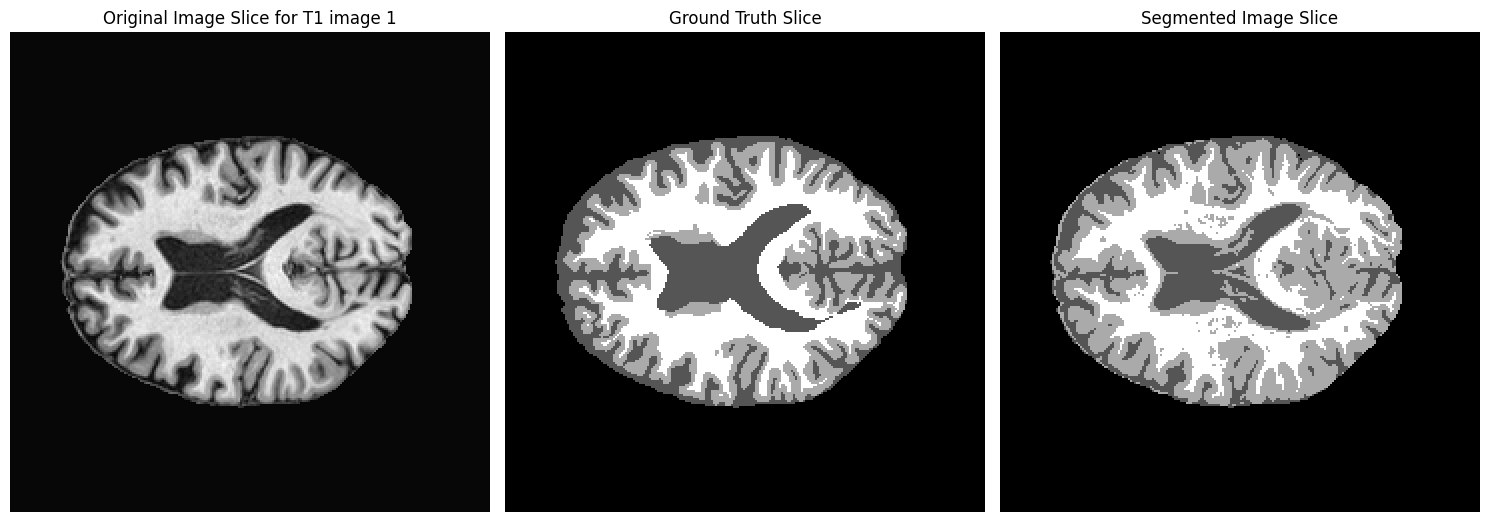

Dice Score: CSF: 0.8513833776132553, GM: 0.8024256824074835, WM: 0.7742590766548311, Avg: 0.8093560455585234


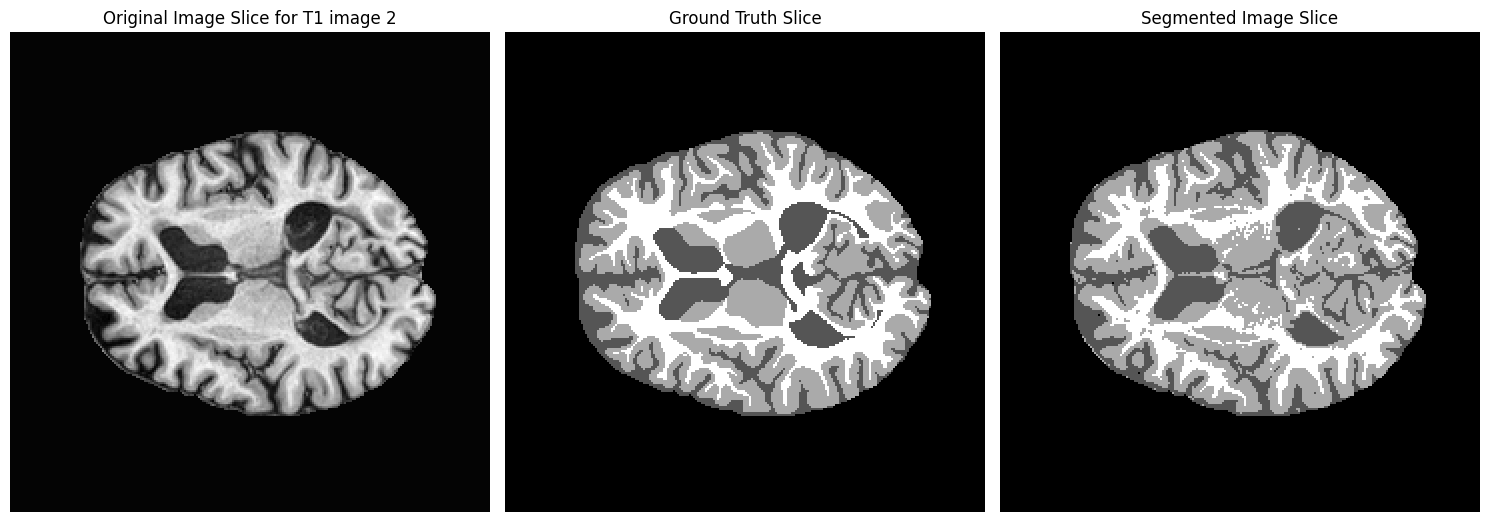

Dice Score: CSF: 0.81113247772305, GM: 0.7769033558245431, WM: 0.8397783830978889, Avg: 0.8092714055484939


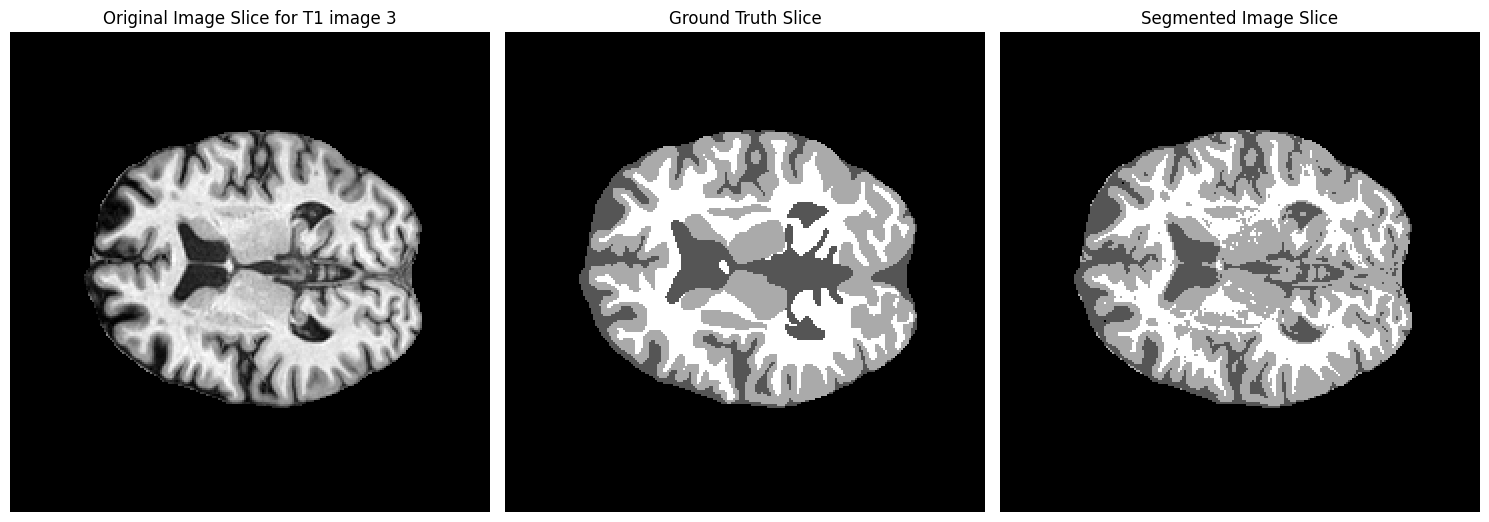

Dice Score: CSF: 0.8054736691754978, GM: 0.8070978030852902, WM: 0.86997268192446, Avg: 0.8275147180617494


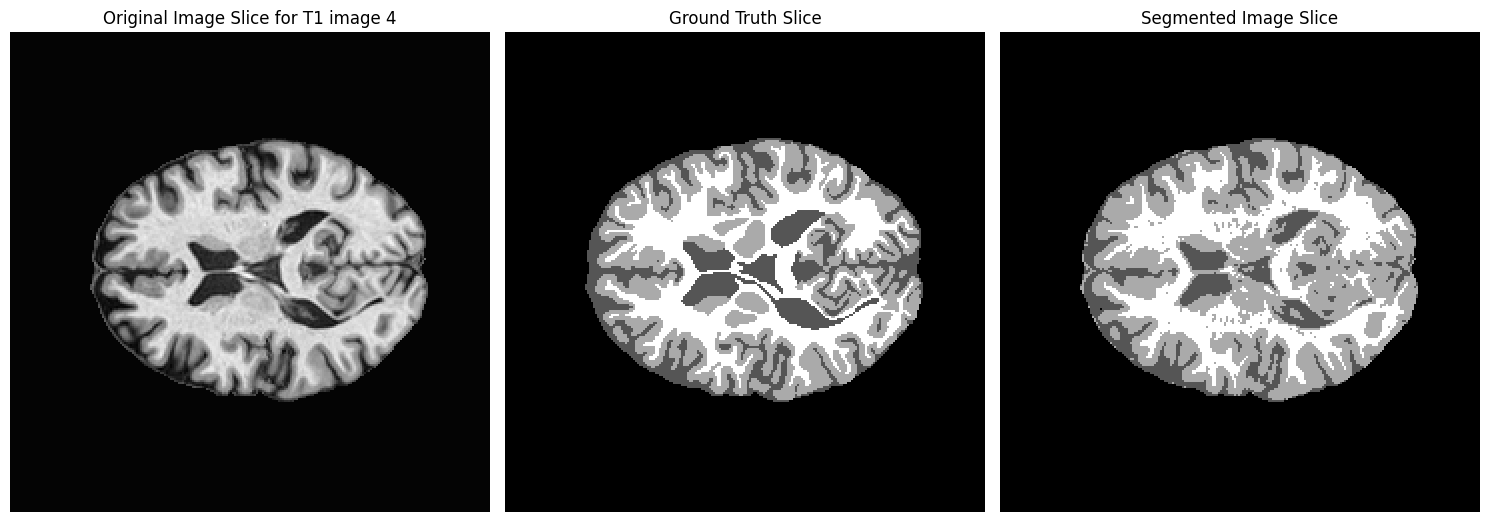

Dice Score: CSF: 0.8024822726744342, GM: 0.8478650541383426, WM: 0.8876940017199946, Avg: 0.8460137761775904


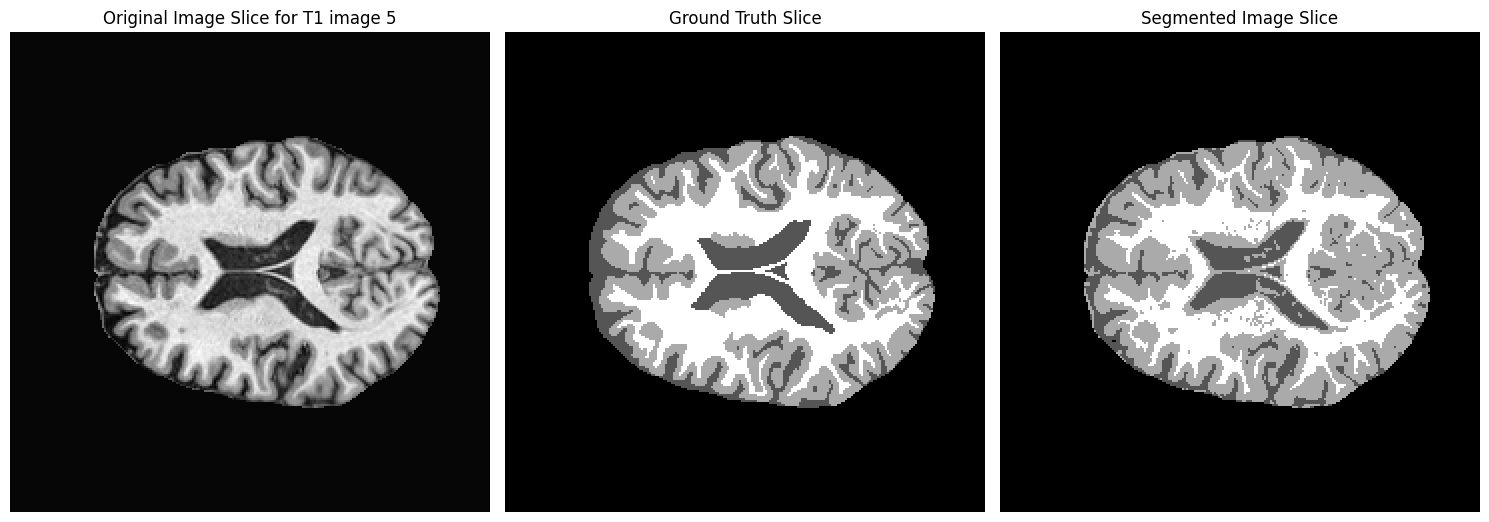

In [4]:
modality = 'T1'
for i in range(5):
    t1_image, _, gt = load_images(i+1)
    t1_image[gt == 0] = 0
    
    t1_data = reshape_images(t1_image)
    prediction, means, variances, mixing_coeffs = expectation_maximization(t1_data, num_classes=4)
    # print(f"Final means: {means}")
    # print(f"Final variances: {variances}")
    # print(f"Final mixing coefficients: {mixing_coeffs}")
    prediction = reshape_data(prediction, t1_image)
    prediction = relabel(prediction, t1_image)
    # nib.save(nib.Nifti1Image(prediction, np.eye(4)), f'segmented_{modality}_{i+1}.nii')
    show_results(t1_image, gt, prediction, modality='T1', i=i)

# T2 images

Dice Score: CSF: 0.644339317913261, GM: 0.19548492539098314, WM: 0.5358759793600159, Avg: 0.4585667408880867


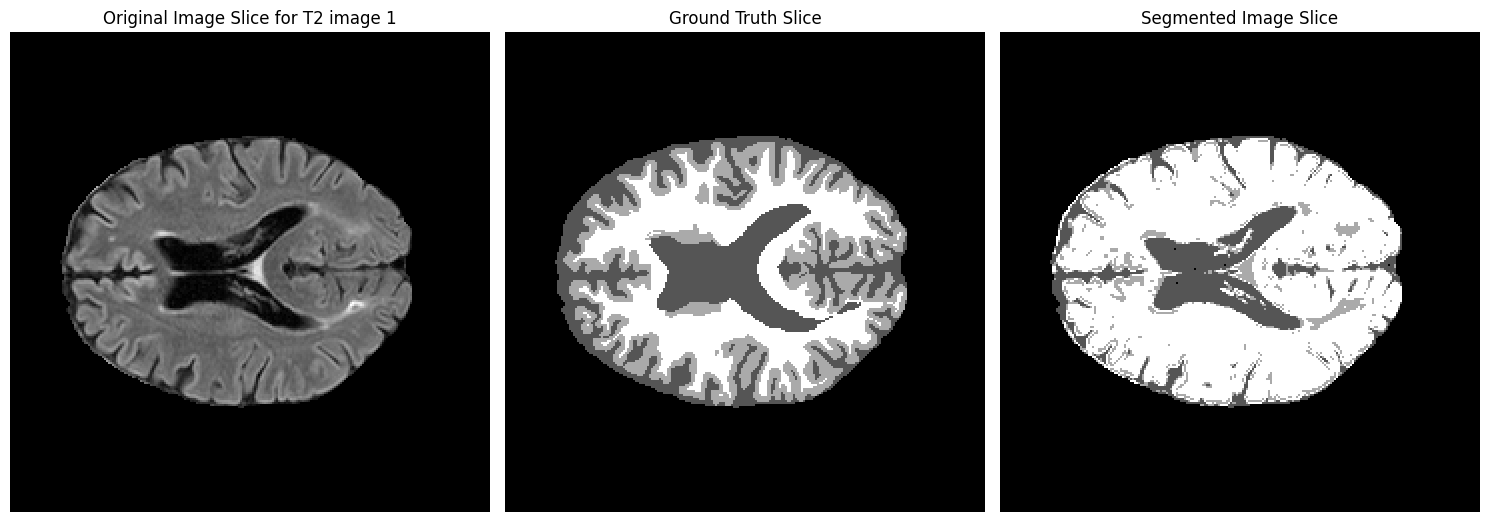

Dice Score: CSF: 0.8032342500627487, GM: 0.7035298851415612, WM: 0.18133076094759512, Avg: 0.5626982987173017


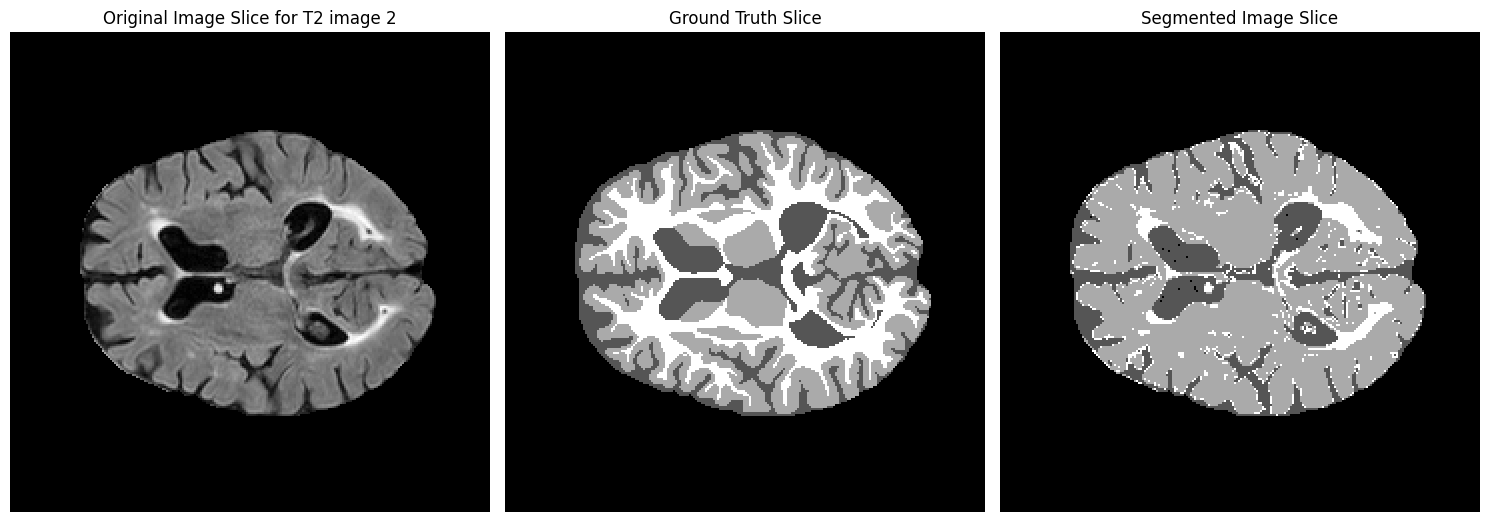

Dice Score: CSF: 0.6868232014581322, GM: 0.6101486674009249, WM: 0.0825696520314025, Avg: 0.45984717363015326


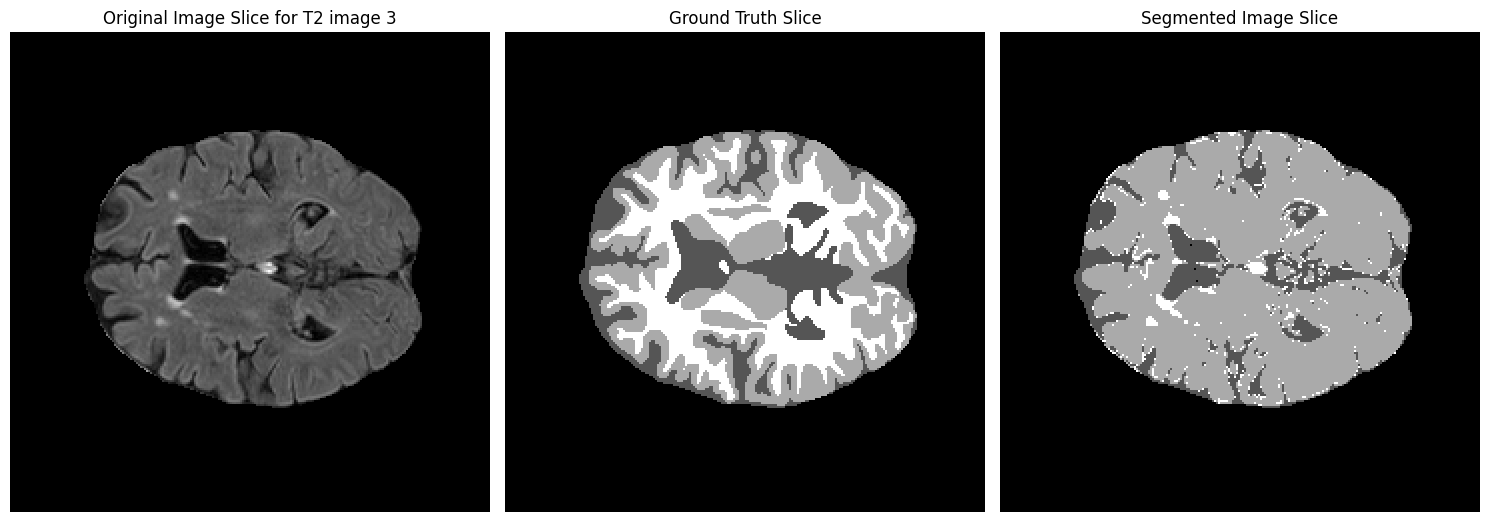

Dice Score: CSF: 0.7128430315024165, GM: 0.5752269428522226, WM: 0.17782180669927558, Avg: 0.48863059368463824


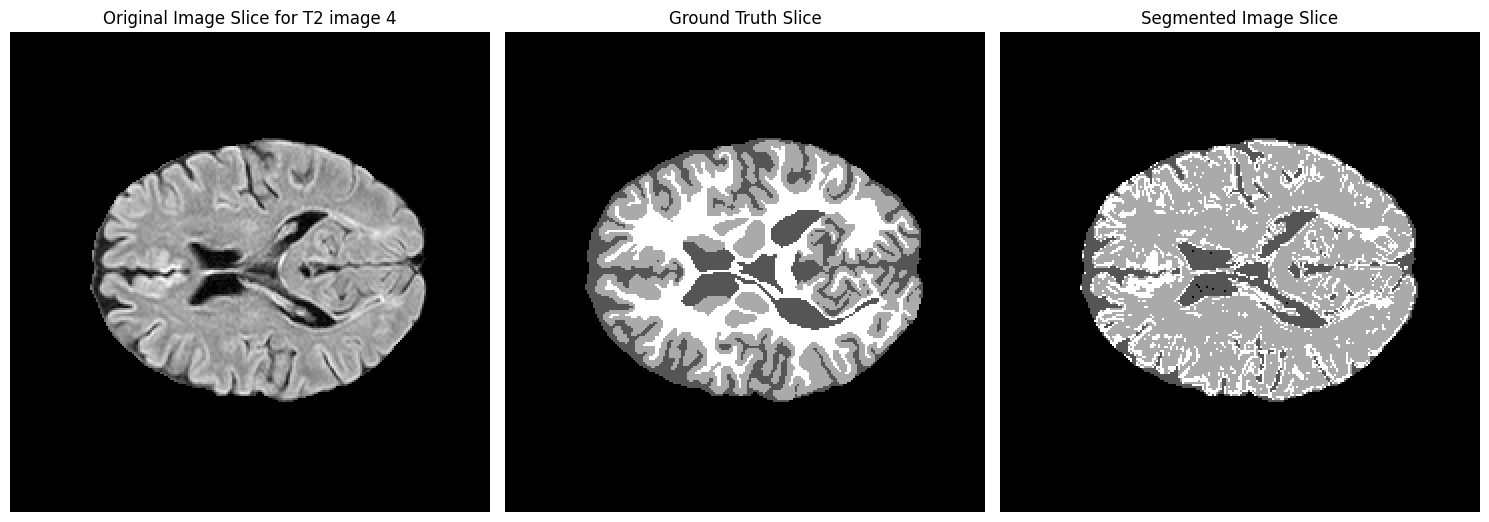

Dice Score: CSF: 0.7419282657542166, GM: 0.6167791167663197, WM: 0.12378531643711174, Avg: 0.49416423298588263


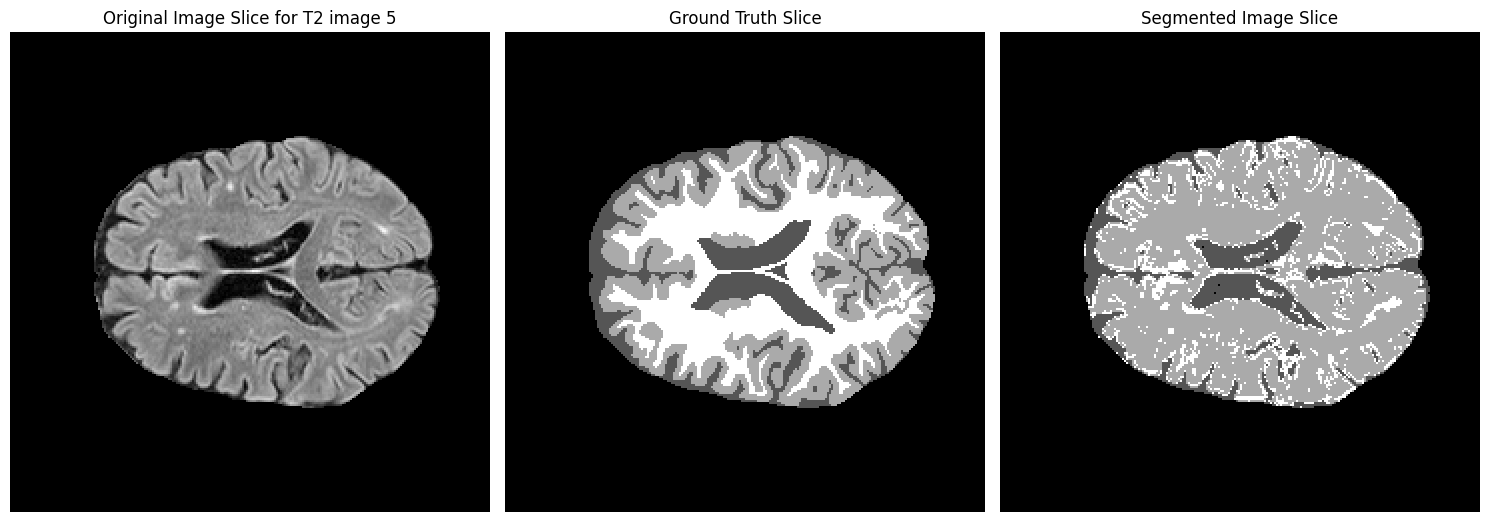

In [5]:
modality = 'T2'
for i in range(5):
    _, t2_image, gt = load_images(i+1)
    t2_image[gt == 0] = 0
    
    t2_data = reshape_images(t2_image)
    prediction, means, variances, mixing_coeffs = expectation_maximization(t2_data, num_classes=4)
    # print(f"Final means: {means}")
    # print(f"Final variances: {variances}")
    # print(f"Final mixing coefficients: {mixing_coeffs}")
    prediction = reshape_data(prediction, t2_image)
    prediction = relabel(prediction, t2_image)
    # nib.save(nib.Nifti1Image(prediction, np.eye(4)), f'segmented_{modality}_{i+1}.nii')
    show_results(t2_image, gt, prediction, modality='T2', i=i)